# 0050 vs TW50｜AI Signal Quality Validation v1

這份 Notebook 的目的不是證明策略已可實盤，而是把 `v1.1 No Overnight` 產生的 361 筆 candidate signals 做成可重現的分析流程。

核心問題：

> 進場當下的特徵，能不能分辨這筆 candidate signal 比較像 Strong、Weak，還是 Failed？

流程：讀取資料 → 檢查欄位 → 分箱分析 → 時間切分 → 簡單模型 → Signal Quality Score → 匯出結果。

（背後意義：這是把「策略回測結果」升級成「可標記、可驗證、可用 AI 輔助篩選訊號品質」的研究流程。）

## 0. 使用方式

1. 先把 `0050_v1_1_ai_event_dataset_full_features.csv` 上傳到 Colab。
2. 從上到下執行。
3. 先看分箱分析，再看模型結果。
4. 不要只看模型準確率，要看 Top score / Bottom score 的 Profit Factor 差異。

（背後意義：模型不是用來炫技，而是檢查它能否把高品質訊號排在前面、低品質訊號排在後面。）

In [ ]:
# === 1. 基本套件 ===
# （這些套件分別負責：資料整理 pandas、數值計算 numpy、畫圖 matplotlib、機器學習 sklearn）
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

In [ ]:
# === 2. 上傳 CSV ===
# （如果你在 Colab 執行，這段會跳出上傳按鈕；請上傳完整特徵版 CSV）
try:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
except Exception:
    # （如果不是在 Colab，而是在本機 / ChatGPT 環境，請把檔名放在同資料夾）
    DATA_PATH = '0050_v1_1_ai_event_dataset_full_features.csv'

print('DATA_PATH =', DATA_PATH)

Saving 0050_v1_1_ai_event_dataset_full_features.csv to 0050_v1_1_ai_event_dataset_full_features (1).csv
DATA_PATH = 0050_v1_1_ai_event_dataset_full_features (1).csv


In [ ]:
# === 3. 讀取資料 ===
# （一列 = 一筆 candidate trade / event sample）
df = pd.read_csv(DATA_PATH)

# 時間欄位轉成 datetime，後續方便切年、切月份、排序。
for col in ['entry_time', 'exit_time', 'entry_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('資料筆數與欄位數:', df.shape)
display(df.head())
print('\n欄位清單：')
print(df.columns.tolist())

資料筆數與欄位數: (361, 51)


,trade_id,entry_time,exit_time,entry_date,entry_year,entry_month,entry_weekday,entry_time_hhmm,data_split,session_id,session_block,is_2025_high_prob_session,minutes_since_open,minutes_to_close,signal_count_today,entry_price,exit_price,qty,position_value_twd,pnl_twd,pnl_pct,mfe_twd,mfe_pct,mae_twd,mae_pct,cum_pnl_twd,cum_pnl_pct,bars_held,holding_minutes,exit_reason,exit_relative_deviation,entry_relative_deviation,volume_ratio_at_entry,deviation_slope_1bar,deviation_slope_3bar,etf_return_5m,etf_return_15m,tw50_return_5m,tw50_return_15m,realized_vol_10bar,rd_bucket,volume_bucket,slope_1bar_bucket,tw50_5m_direction,profit_flag,label_prelim,label_id_prelim,quality_label,quality_label_id,entry_feature_string,exit_feature_string
0,1,2022-06-01 09:40:00,2022-06-01 09:50:00,2022-06-01,2022,6,Wed,09:40,Train_探索_2022_2024,2,早盤_0905_0945,0,35.0,235.0,1,32.45,32.45,1.0,32.45,0.0,0.00,0.00,0.00,-0.05,-0.15,0.0,0.0,2.0,10.0,EXIT_TIME,-0.1218,-0.2445,2.1142,-0.0724,-0.1382,0.1931,0.1157,0.2648,0.2533,0.1297,-0.3 ~ -0.2,2 ~ 3,惡化中_負斜率,上行,0,Weak_Flat_暫定,2,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2445|VR=2.1142|S1=-0.0724|S3=-0.13...,EXIT_TIME|XRD=-0.1218|BH=2
1,2,2022-06-01 10:25:00,2022-06-01 10:35:00,2022-06-01,2022,6,Wed,10:25,Train_探索_2022_2024,4,盤中_1000_1245,0,80.0,190.0,2,32.50,32.50,1.0,32.50,0.0,0.00,0.00,0.00,-0.05,-0.15,0.0,0.0,2.0,10.0,EXIT_TIME,-0.1656,-0.2473,2.2161,-0.0665,-0.2773,0.0385,0.0000,0.1044,0.2758,0.0845,-0.3 ~ -0.2,2 ~ 3,惡化中_負斜率,上行,0,Weak_Flat_暫定,2,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2473|VR=2.2161|S1=-0.0665|S3=-0.27...,EXIT_TIME|XRD=-0.1656|BH=2
2,3,2022-06-14 12:05:00,2022-06-14 12:15:00,2022-06-14,2022,6,Tue,12:05,Train_探索_2022_2024,4,盤中_1000_1245,0,180.0,90.0,1,30.75,30.85,1.0,30.75,0.1,0.33,0.10,0.33,0.00,0.00,0.1,0.0,2.0,10.0,EXIT_TIME,-0.1405,-0.2884,2.0584,-0.0010,-0.1371,0.2445,0.3672,0.2448,0.5038,0.0824,-0.3 ~ -0.2,2 ~ 3,近乎持平,上行,1,Strong_Profit_暫定,1,Strong_Profit_NonReversion,2,ENTRY|RD=-0.2884|VR=2.0584|S1=-0.001|S3=-0.137...,EXIT_TIME|XRD=-0.1405|BH=2
3,4,2022-06-17 13:00:00,2022-06-17 13:10:00,2022-06-17,2022,6,Fri,13:00,Train_探索_2022_2024,5,午盤尾段_1245_1300,1,235.0,35.0,1,30.20,30.20,1.0,30.20,0.0,0.00,0.05,0.17,-0.05,-0.17,0.1,0.0,2.0,10.0,EXIT_TIME,-0.2182,-0.2437,1.6271,-0.1682,-0.1810,-0.0827,-0.1654,0.0857,0.0157,0.1146,-0.3 ~ -0.2,1.5 ~ 2,惡化中_負斜率,上行,0,Weak_Flat_暫定,2,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2437|VR=1.6271|S1=-0.1682|S3=-0.18...,EXIT_TIME|XRD=-0.2182|BH=2
4,5,2022-06-22 10:50:00,2022-06-22 11:00:00,2022-06-22,2022,6,Wed,10:50,Train_探索_2022_2024,4,盤中_1000_1245,0,105.0,165.0,1,30.00,29.90,1.0,30.00,-0.1,-0.33,0.00,0.00,-0.10,-0.33,0.0,0.0,2.0,10.0,EXIT_TIME,-0.1744,-0.2228,1.9967,-0.1052,-0.0387,-0.1248,-0.2908,-0.0186,-0.2513,0.0834,-0.3 ~ -0.2,1.5 ~ 2,惡化中_負斜率,平盤,0,Failed_Loss_暫定,0,Failed_Loss_or_Stop,0,ENTRY|RD=-0.2228|VR=1.9967|S1=-0.1052|S3=-0.03...,EXIT_TIME|XRD=-0.1744|BH=2



欄位清單：
['trade_id', 'entry_time', 'exit_time', 'entry_date', 'entry_year', 'entry_month', 'entry_weekday', 'entry_time_hhmm', 'data_split', 'session_id', 'session_block', 'is_2025_high_prob_session', 'minutes_since_open', 'minutes_to_close', 'signal_count_today', 'entry_price', 'exit_price', 'qty', 'position_value_twd', 'pnl_twd', 'pnl_pct', 'mfe_twd', 'mfe_pct', 'mae_twd', 'mae_pct', 'cum_pnl_twd', 'cum_pnl_pct', 'bars_held', 'holding_minutes', 'exit_reason', 'exit_relative_deviation', 'entry_relative_deviation', 'volume_ratio_at_entry', 'deviation_slope_1bar', 'deviation_slope_3bar', 'etf_return_5m', 'etf_return_15m', 'tw50_return_5m', 'tw50_return_15m', 'realized_vol_10bar', 'rd_bucket', 'volume_bucket', 'slope_1bar_bucket', 'tw50_5m_direction', 'profit_flag', 'label_prelim', 'label_id_prelim', 'quality_label', 'quality_label_id', 'entry_feature_string', 'exit_feature_string']


In [ ]:
# === 4. 資料完整性檢查 ===
# （先確認樣本數、時間範圍、label 分布是否正常，避免後面模型建立在髒資料上）
print('entry_time range:', df['entry_time'].min(), '→', df['entry_time'].max())
print('data_split distribution:')
display(df['data_split'].value_counts(dropna=False))

print('quality_label distribution:')
display(df['quality_label'].value_counts(dropna=False))

print('exit_reason distribution:')
display(df['exit_reason'].value_counts(dropna=False))

# 檢查核心特徵缺值
core_features = [
    'entry_relative_deviation', 'volume_ratio_at_entry',
    'deviation_slope_1bar', 'deviation_slope_3bar',
    'etf_return_5m', 'etf_return_15m',
    'tw50_return_5m', 'tw50_return_15m',
    'realized_vol_10bar', 'minutes_since_open', 'minutes_to_close',
    'session_id', 'signal_count_today', 'is_2025_high_prob_session'
]
missing = df[core_features].isna().sum().sort_values(ascending=False)
print('核心特徵缺值：')
display(missing)

entry_time range: 2022-06-01 09:40:00 → 2026-05-28 11:45:00
data_split distribution:


,count
data_split,
Train_探索_2022_2024,174
Validation_驗證_2025,117
Recent_Check_近期_2026,70


quality_label distribution:


,count
quality_label,
Weak_Flat_or_NoMove,136
Failed_Loss_or_Stop,93
Strong_Profit_NonReversion,72
Strong_Reversion_Profit,60


exit_reason distribution:


,count
exit_reason,
EXIT_TIME,202
EXIT_REVERSION,145
EXIT_STOP,14


核心特徵缺值：


,0
entry_relative_deviation,0
volume_ratio_at_entry,0
deviation_slope_1bar,0
deviation_slope_3bar,0
etf_return_5m,0
etf_return_15m,0
tw50_return_5m,0
tw50_return_15m,0
realized_vol_10bar,0
minutes_since_open,0


## 1. Label 設計

這裡先做兩種 label：

1. `target_profit`：獲利 = 1，非獲利 = 0。  
   （用來檢查模型能否分辨「結果上是否賺錢」。）

2. `target_strong_failed`：只保留 Strong 與 Failed，排除 Weak。  
   （用來檢查模型能否分辨「高品質訊號」與「低品質訊號」。）

（背後意義：金融策略不要一開始就把所有樣本混成一團。Weak 樣本常常是模糊區，先排除它，有助於檢查特徵是否真的能分辨強弱。）

In [ ]:
# === 5. 建立 label ===
# （target_profit：最直覺、最粗的 label。獲利 = 1，其他 = 0）
df['target_profit'] = (df['pnl_twd'] > 0).astype(int)

# （target_strong_failed：只用 Strong / Failed，不用 Weak。這更接近 signal quality 分類。）
strong_mask = df['quality_label'].astype(str).str.contains('Strong', na=False)
failed_mask = df['quality_label'].astype(str).str.contains('Failed', na=False)
df['target_strong_failed'] = np.nan
df.loc[strong_mask, 'target_strong_failed'] = 1
df.loc[failed_mask, 'target_strong_failed'] = 0

print('target_profit distribution:')
display(df['target_profit'].value_counts())
print('\ntarget_strong_failed distribution（排除 Weak 後）：')
display(df['target_strong_failed'].value_counts(dropna=False))

target_profit distribution:


,count
target_profit,
0,225
1,136



target_strong_failed distribution（排除 Weak 後）：


,count
target_strong_failed,
NaN,136
1.0,132
0.0,93


## 2. 分箱分析

分箱分析會把連續特徵切成幾段，例如偏離幅度、成交量倍率、斜率、大盤方向，然後看每一段的勝率、Profit Factor、平均損益。

（背後意義：先用人看得懂的方式檢查規律，避免一開始就把資料丟進黑箱模型。）

In [ ]:
# === 6. 工具函數：計算 Profit Factor 與分箱統計 ===
def profit_factor(x):
    gross_profit = x[x > 0].sum()
    gross_loss = -x[x < 0].sum()
    if gross_loss == 0:
        return np.inf if gross_profit > 0 else np.nan
    return gross_profit / gross_loss


def summarize_group(data, group_col, pnl_col='pnl_twd'):
    g = data.groupby(group_col, dropna=False)
    out = g.agg(
        n=('trade_id', 'count'),
        win_rate=('target_profit', 'mean'),
        avg_pnl=(pnl_col, 'mean'),
        median_pnl=(pnl_col, 'median'),
        total_pnl=(pnl_col, 'sum'),
        strong_ratio=('quality_label', lambda s: s.astype(str).str.contains('Strong', na=False).mean()),
        failed_ratio=('quality_label', lambda s: s.astype(str).str.contains('Failed', na=False).mean()),
        weak_ratio=('quality_label', lambda s: s.astype(str).str.contains('Weak', na=False).mean()),
        max_loss=(pnl_col, 'min'),
        max_win=(pnl_col, 'max'),
        pf=(pnl_col, profit_factor),
    ).reset_index()
    return out.sort_values('n', ascending=False)

In [ ]:
# === 7. 建立分箱欄位 ===
# （這些 bucket 是用來看每個區間的訊號品質，而不是直接拿來當最終交易規則。）
work = df.copy()

work['rd_bucket_custom'] = pd.cut(
    work['entry_relative_deviation'],
    bins=[-np.inf, -0.6, -0.4, -0.3, -0.2],
    labels=['RD < -0.6', '-0.6 ~ -0.4', '-0.4 ~ -0.3', '-0.3 ~ -0.2']
)

work['vr_bucket_custom'] = pd.cut(
    work['volume_ratio_at_entry'],
    bins=[1.5, 2, 3, 5, np.inf],
    labels=['1.5 ~ 2', '2 ~ 3', '3 ~ 5', '> 5'],
    include_lowest=True
)

work['slope1_bucket_custom'] = pd.cut(
    work['deviation_slope_1bar'],
    bins=[-np.inf, -0.1, -0.02, 0.02, 0.1, np.inf],
    labels=['強惡化 < -0.1', '輕惡化 -0.1~-0.02', '近乎持平', '輕修復 0.02~0.1', '強修復 > 0.1']
)

work['tw50_5m_dir_custom'] = np.where(work['tw50_return_5m'] > 0, 'TW50_5m_上行', 'TW50_5m_下行或持平')

# 檢視幾個核心分箱
for col in ['data_split', 'session_block', 'rd_bucket_custom', 'vr_bucket_custom', 'slope1_bucket_custom', 'tw50_5m_dir_custom']:
    print(f'\n==== {col} ====')
    display(summarize_group(work, col))


==== data_split ====


,data_split,n,win_rate,avg_pnl,median_pnl,total_pnl,strong_ratio,failed_ratio,weak_ratio,max_loss,max_win,pf
1,Train_探索_2022_2024,174,0.304598,0.008908,0.00,1.55,0.298851,0.218391,0.482759,-0.15,0.20,1.673913
2,Validation_驗證_2025,117,0.367521,0.015385,0.00,1.80,0.350427,0.324786,0.324786,-0.30,0.65,1.666667
0,Recent_Check_近期_2026,70,0.571429,0.057143,0.05,4.00,0.557143,0.242857,0.200000,-0.55,0.65,2.600000



==== session_block ====


,session_block,n,win_rate,avg_pnl,median_pnl,total_pnl,strong_ratio,failed_ratio,weak_ratio,max_loss,max_win,pf
3,盤中_1000_1245,188,0.324468,0.012766,0.000,2.40,0.313830,0.234043,0.452128,-0.15,0.65,1.941176
1,早盤_0905_0945,114,0.500000,0.040351,0.025,4.60,0.482456,0.254386,0.263158,-0.55,0.65,2.437500
0,午盤尾段_1245_1300,41,0.365854,0.012195,0.000,0.50,0.365854,0.268293,0.365854,-0.15,0.15,1.625000
2,早盤中段_0945_1000,18,0.166667,-0.008333,-0.025,-0.15,0.166667,0.500000,0.333333,-0.35,0.45,0.842105



==== rd_bucket_custom ====


...


==== slope1_bucket_custom ====


/tmp/ipykernel_6435/3633008357.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(group_col, dropna=False)


,slope1_bucket_custom,n,win_rate,avg_pnl,median_pnl,total_pnl,strong_ratio,failed_ratio,weak_ratio,max_loss,max_win,pf
0,強惡化 < -0.1,203,0.438424,0.034236,0.00,6.95,0.428571,0.246305,0.325123,-0.25,0.65,2.759494
1,輕惡化 -0.1~-0.02,93,0.279570,0.006452,0.00,0.60,0.268817,0.247312,0.483871,-0.35,0.25,1.352941
2,近乎持平,32,0.250000,0.006250,0.00,0.20,0.218750,0.218750,0.562500,-0.30,0.25,1.363636
3,輕修復 0.02~0.1,28,0.464286,0.016071,0.00,0.45,0.464286,0.357143,0.178571,-0.10,0.15,2.000000
4,強修復 > 0.1,5,0.000000,-0.170000,-0.05,-0.85,0.000000,0.600000,0.400000,-0.55,0.00,0.000000



==== tw50_5m_dir_custom ====


,tw50_5m_dir_custom,n,win_rate,avg_pnl,median_pnl,total_pnl,strong_ratio,failed_ratio,weak_ratio,max_loss,max_win,pf
0,TW50_5m_上行,246,0.406504,0.031098,0.0,7.65,0.390244,0.219512,0.390244,-0.35,0.65,2.821429
1,TW50_5m_下行或持平,115,0.313043,-0.002609,0.0,-0.30,0.313043,0.339130,0.347826,-0.55,0.25,0.909091


/tmp/ipykernel_6435/3300002648.py:11: UserWarning: Glyph 26089 (\N{CJK UNIFIED IDEOGRAPH-65E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6435/3300002648.py:11: UserWarning: Glyph 30436 (\N{CJK UNIFIED IDEOGRAPH-76E4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6435/3300002648.py:11: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6435/3300002648.py:11: UserWarning: Glyph 21320 (\N{CJK UNIFIED IDEOGRAPH-5348}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6435/3300002648.py:11: UserWarning: Glyph 23614 (\N{CJK UNIFIED IDEOGRAPH-5C3E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6435/3300002648.py:11: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 260

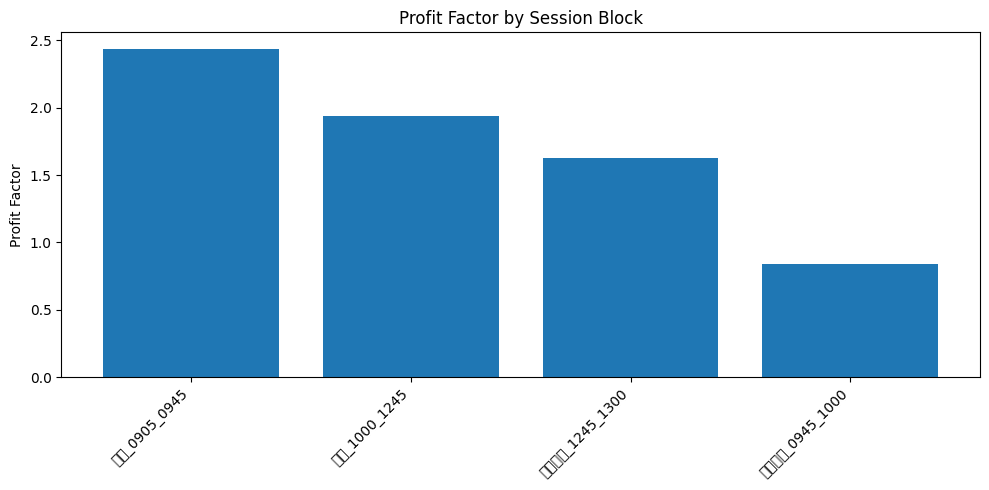

In [ ]:
# === 8. 分箱視覺化：各時段 Profit Factor ===
# （用來檢查不同時段的訊號品質，而不是只看整體績效。）
session_summary = summarize_group(work, 'session_block')
plot_df = session_summary.replace([np.inf, -np.inf], np.nan).dropna(subset=['pf']).sort_values('pf', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df['session_block'].astype(str), plot_df['pf'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Profit Factor')
plt.title('Profit Factor by Session Block')
plt.tight_layout()
plt.show()

## 3. 簡單模型：Signal Quality Score

這裡先用三種模型：

1. Logistic Regression（線性基準模型）  
2. Decision Tree（直覺規則模型）  
3. Random Forest（簡單非線性組合模型）

（背後意義：不是要一開始追求最強模型，而是先檢查「這些特徵是否有可泛化的分辨力」。）

In [ ]:
# === 9. 準備模型資料 ===
# （只使用進場當下可取得的特徵。不能把 pnl、exit_reason、MFE、MAE 當輸入，否則會資料洩漏。）
feature_cols = [
    'entry_relative_deviation',
    'volume_ratio_at_entry',
    'deviation_slope_1bar',
    'deviation_slope_3bar',
    'etf_return_5m',
    'etf_return_15m',
    'tw50_return_5m',
    'tw50_return_15m',
    'realized_vol_10bar',
    'minutes_since_open',
    'minutes_to_close',
    'session_id',
    'signal_count_today',
    'is_2025_high_prob_session',
]

# 模型目標：第一版先用 target_profit；你也可以改成 target_strong_failed。
TARGET = 'target_profit'
model_df = work.dropna(subset=feature_cols + [TARGET]).copy()

train_df = model_df[model_df['data_split'].astype(str).str.contains('Train')].copy()
val_df = model_df[model_df['data_split'].astype(str).str.contains('Validation')].copy()
recent_df = model_df[model_df['data_split'].astype(str).str.contains('Recent')].copy()

print('train/val/recent sizes:', len(train_df), len(val_df), len(recent_df))

X_train, y_train = train_df[feature_cols], train_df[TARGET].astype(int)
X_val, y_val = val_df[feature_cols], val_df[TARGET].astype(int)
X_recent, y_recent = recent_df[feature_cols], recent_df[TARGET].astype(int)

train/val/recent sizes: 174 117 70


In [ ]:
# === 10. 建立模型 pipeline ===
# （numeric 特徵先補缺值、標準化；session_id 先當數值處理，第一版保持簡單。）
numeric_features = feature_cols
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='drop'
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'DecisionTree_depth3': DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42, class_weight='balanced'),
    'RandomForest_depth4': RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=10, random_state=42, class_weight='balanced'),
}

pipelines = {name: Pipeline(steps=[('preprocess', preprocess), ('model', model)]) for name, model in models.items()}

In [ ]:
# === 11. 模型評估函數 ===
# （AUC 看排序能力；F1/Precision/Recall 看分類能力。但金融策略更重要的是 score 分組後的 Profit Factor。）
def evaluate_model(pipe, X, y, split_name):
    pred = pipe.predict(X)
    if hasattr(pipe, 'predict_proba'):
        proba = pipe.predict_proba(X)[:, 1]
    else:
        proba = pred
    out = {
        'split': split_name,
        'n': len(y),
        'accuracy': accuracy_score(y, pred),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
    }
    try:
        out['auc'] = roc_auc_score(y, proba)
    except Exception:
        out['auc'] = np.nan
    return out, proba

metrics = []
score_tables = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    for split_name, X, y, part in [
        ('Train_2022_2024', X_train, y_train, train_df),
        ('Validation_2025', X_val, y_val, val_df),
        ('Recent_2026', X_recent, y_recent, recent_df),
    ]:
        m, proba = evaluate_model(pipe, X, y, split_name)
        m['model'] = name
        metrics.append(m)
        tmp = part[['trade_id', 'entry_time', 'data_split', 'pnl_twd', 'quality_label', 'target_profit']].copy()
        tmp['model'] = name
        tmp['score'] = proba
        score_tables.append(tmp)

metrics_df = pd.DataFrame(metrics)[['model','split','n','accuracy','precision','recall','f1','auc']]
display(metrics_df)

,model,split,n,accuracy,precision,recall,f1,auc
0,LogisticRegression,Train_2022_2024,174,0.660920,0.457143,0.603774,0.520325,0.686262
1,LogisticRegression,Validation_2025,117,0.547009,0.410714,0.534884,0.464646,0.552483
2,LogisticRegression,Recent_2026,70,0.471429,0.540541,0.500000,0.519481,0.420000
3,DecisionTree_depth3,Train_2022_2024,174,0.574713,0.414634,0.962264,0.579545,0.737720
4,DecisionTree_depth3,Validation_2025,117,0.444444,0.369048,0.720930,0.488189,0.541955
5,DecisionTree_depth3,Recent_2026,70,0.514286,0.548387,0.850000,0.666667,0.434583
6,RandomForest_depth4,Train_2022_2024,174,0.798851,0.655172,0.716981,0.684685,0.885233
7,RandomForest_depth4,Validation_2025,117,0.547009,0.410714,0.534884,0.464646,0.573853
8,RandomForest_depth4,Recent_2026,70,0.485714,0.550000,0.550000,0.550000,0.501667


In [ ]:
# === 12. Signal Quality Score 分組 ===
# （真正要看的是：模型分數高的交易組，是否比低分組有更好的 Profit Factor。）
all_scores = pd.concat(score_tables, ignore_index=True)

def assign_score_bucket(s):
    # 依每個 model + split 內部做分位數分組：低 30%、中 40%、高 30%。
    try:
        return pd.qcut(s, q=[0, 0.3, 0.7, 1.0], labels=['Bottom_30%', 'Middle_40%', 'Top_30%'], duplicates='drop')
    except Exception:
        return pd.Series(['Unknown'] * len(s), index=s.index)

all_scores['score_bucket'] = all_scores.groupby(['model','data_split'])['score'].transform(assign_score_bucket)

score_summary = all_scores.groupby(['model','data_split','score_bucket'], dropna=False).agg(
    n=('trade_id','count'),
    win_rate=('target_profit','mean'),
    avg_pnl=('pnl_twd','mean'),
    total_pnl=('pnl_twd','sum'),
    pf=('pnl_twd', profit_factor),
).reset_index()

# 方便閱讀：先看 RandomForest
rf_summary = score_summary[score_summary['model'] == 'RandomForest_depth4']
display(rf_summary)

,model,data_split,score_bucket,n,win_rate,avg_pnl,total_pnl,pf
16,RandomForest_depth4,Recent_Check_近期_2026,Bottom_30%,21,0.571429,0.033333,0.70,2.400000
17,RandomForest_depth4,Recent_Check_近期_2026,Middle_40%,28,0.535714,0.060714,1.70,3.000000
18,RandomForest_depth4,Recent_Check_近期_2026,Top_30%,21,0.619048,0.076190,1.60,2.391304
19,RandomForest_depth4,Train_探索_2022_2024,Bottom_30%,52,0.000000,-0.012500,-0.65,0.000000
20,RandomForest_depth4,Train_探索_2022_2024,Middle_40%,70,0.242857,0.002143,0.15,1.150000
21,RandomForest_depth4,Train_探索_2022_2024,Top_30%,52,0.692308,0.039423,2.05,4.153846
22,RandomForest_depth4,Validation_驗證_2025,Bottom_30%,35,0.285714,-0.007143,-0.25,0.736842
23,RandomForest_depth4,Validation_驗證_2025,Middle_40%,47,0.382979,0.005319,0.25,1.250000
24,RandomForest_depth4,Validation_驗證_2025,Top_30%,35,0.428571,0.051429,1.80,3.400000


,feature,importance
8,realized_vol_10bar,0.122430
7,tw50_return_15m,0.110838
10,minutes_to_close,0.104285
3,deviation_slope_3bar,0.102551
9,minutes_since_open,0.095734
2,deviation_slope_1bar,0.090197
5,etf_return_15m,0.086684
6,tw50_return_5m,0.074981
1,volume_ratio_at_entry,0.062903
4,etf_return_5m,0.058457


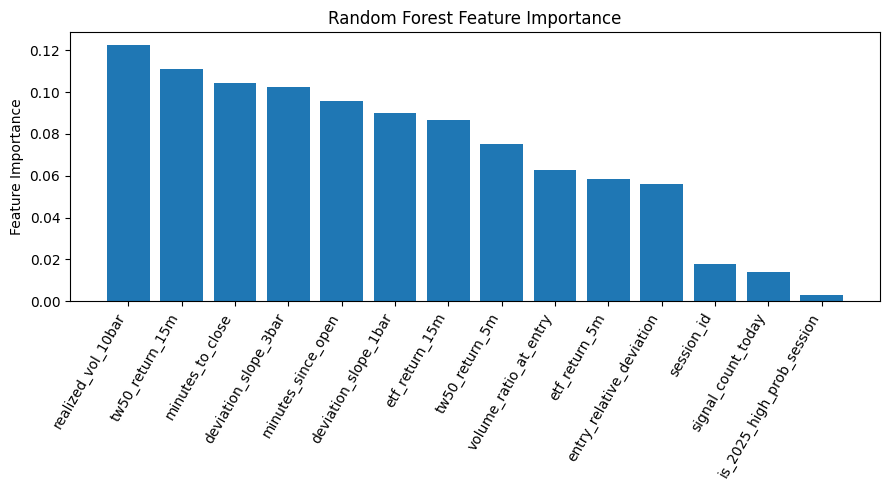

In [ ]:
# === 13. Random Forest 特徵重要性 ===
# （用來初步看模型認為哪些特徵比較有分辨力；注意這只是提示，不是絕對因果。）
rf_pipe = pipelines['RandomForest_depth4']
rf_model = rf_pipe.named_steps['model']
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

plt.figure(figsize=(9, 5))
plt.bar(importance_df['feature'], importance_df['importance'])
plt.xticks(rotation=60, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# === 14. 匯出分析結果 ===
# （把分箱、模型指標、score 分組、特徵重要性輸出成 Excel，方便貼到簡報或後續整理。）
output_path = '0050_colab_ai_validation_outputs.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summarize_group(work, 'data_split').to_excel(writer, sheet_name='By_Data_Split', index=False)
    summarize_group(work, 'session_block').to_excel(writer, sheet_name='By_Session', index=False)
    summarize_group(work, 'rd_bucket_custom').to_excel(writer, sheet_name='By_RD_Bucket', index=False)
    summarize_group(work, 'vr_bucket_custom').to_excel(writer, sheet_name='By_Volume_Bucket', index=False)
    summarize_group(work, 'slope1_bucket_custom').to_excel(writer, sheet_name='By_Slope_Bucket', index=False)
    summarize_group(work, 'tw50_5m_dir_custom').to_excel(writer, sheet_name='By_TW50_Direction', index=False)
    metrics_df.to_excel(writer, sheet_name='Model_Metrics', index=False)
    score_summary.to_excel(writer, sheet_name='Score_Buckets', index=False)
    importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)

print('已輸出：', output_path)

# Colab 下載
try:
    from google.colab import files
    files.download(output_path)
except Exception:
    pass

已輸出： 0050_colab_ai_validation_outputs.xlsx


/tmp/ipykernel_6435/3633008357.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(group_col, dropna=False)
/tmp/ipykernel_6435/3633008357.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(group_col, dropna=False)
/tmp/ipykernel_6435/3633008357.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(group_col, dropna=False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. 你應該怎麼解讀結果？

重點不是看模型準確率有多高，而是看：

1. Validation / Recent 的 AUC 是否高於 0.5。  
   （代表模型排序能力是否比亂猜好。）

2. Random Forest / Logistic 的 Top 30% score 組，Profit Factor 是否高於 Bottom 30%。  
   （代表模型分數是否真的能排序訊號品質。）

3. 分箱結果是否有市場邏輯。  
   例如 TW50 上行時訊號更好，就合理；如果只出現奇怪時段或樣本太少，要保守。

4. 如果模型在 Train 很好、Validation / Recent 很差，代表可能過度擬合。  
   （不要拿訓練集好結果去說策略有效。）

（背後意義：AI 驗證不是追求漂亮數字，而是檢查訊號品質是否能被穩定、可解釋、樣本外不崩潰地分辨。）

## 5. 下一步升級方向

第一版跑完後，不要急著加複雜模型。下一步建議：

1. 改善 label：從單純 pnl > 0，升級成 `回補幅度 + MAE + exit_reason` 的 Strong / Weak / Failed。  
   （背後意義：讓模型學「訊號品質」，而不是只學最後有沒有賺一點。）

2. 做 walk-forward validation。  
   （背後意義：用滾動時間切分檢查規律是否穩定，降低過擬合。）

3. 檢查 Top score 策略是否能改善 Profit Factor。  
   （背後意義：AI 要有用，必須讓高分組比原始 v1.1 更好。）

4. 最後才設計 v2 濾網。  
   （背後意義：濾網要從資料證據與市場邏輯推導，不要手動亂調參。）

# 8. v1.1 vs v2-A 策略升級驗證

本段目的不是重新尋找新模型，而是檢查前一階段 Colab 分箱分析發現的 TW50_return_5m > 0 濾網，是否在 TradingView 回測中真的能改善 v1.1 的訊號品質。

研究邏輯：

1. v1.1 產生原始 candidate signals。
2. Colab 分箱發現 TW50 5m 上行時，訊號品質明顯較好。
3. 回到 TradingView 將 TW50_return_5m > 0 寫成 v2-A 條件。
4. 現在比較 v1.1 與 v2-A 的交易數、勝率、Profit Factor、最大虧損與時間切分穩定性。

In [ ]:
import os
import numpy as np
import pandas as pd

# =========================
# 1. Load files
# =========================

v1_candidates = [
    "0050_v1_1_ai_event_dataset_full_features.csv",
    "0050_v1_1_ai_event_dataset_full_features (1).csv"
]

v2_candidates = [
    "0050_v2A_ai_event_dataset_full_features_FIXED.csv",
    "0050_v2A_ai_event_dataset_full_features.csv",
    "0050_v2A_ai_event_dataset_full_features (1).csv"
]

def find_file(candidates):
    for f in candidates:
        if os.path.exists(f):
            return f
    raise FileNotFoundError("No file found from candidates: " + str(candidates))

v1_path = find_file(v1_candidates)
v2_path = find_file(v2_candidates)

print("v1 file:", v1_path)
print("v2 file:", v2_path)

v1 = pd.read_csv(v1_path)
v2 = pd.read_csv(v2_path)

v1["version"] = "v1_1"
v2["version"] = "v2A"

print("v1 rows:", len(v1))
print("v2 rows:", len(v2))

display(v1.head())
display(v2.head())

v1 file: 0050_v1_1_ai_event_dataset_full_features.csv
v2 file: 0050_v2A_ai_event_dataset_full_features_FIXED.csv
v1 rows: 361
v2 rows: 258


,trade_id,entry_time,exit_time,entry_date,entry_year,entry_month,entry_weekday,entry_time_hhmm,data_split,session_id,session_block,is_2025_high_prob_session,minutes_since_open,minutes_to_close,signal_count_today,entry_price,exit_price,qty,position_value_twd,pnl_twd,pnl_pct,mfe_twd,mfe_pct,mae_twd,mae_pct,cum_pnl_twd,cum_pnl_pct,bars_held,holding_minutes,exit_reason,exit_relative_deviation,entry_relative_deviation,volume_ratio_at_entry,deviation_slope_1bar,deviation_slope_3bar,etf_return_5m,etf_return_15m,tw50_return_5m,tw50_return_15m,realized_vol_10bar,rd_bucket,volume_bucket,slope_1bar_bucket,tw50_5m_direction,profit_flag,label_prelim,label_id_prelim,quality_label,quality_label_id,entry_feature_string,exit_feature_string,version
0,1,2022-06-01 09:40,2022-06-01 09:50,2022-06-01,2022,6,Wed,09:40,Train_探索_2022_2024,2,早盤_0905_0945,0,35.0,235.0,1,32.45,32.45,1.0,32.45,0.0,0.00,0.00,0.00,-0.05,-0.15,0.0,0.0,2.0,10.0,EXIT_TIME,-0.1218,-0.2445,2.1142,-0.0724,-0.1382,0.1931,0.1157,0.2648,0.2533,0.1297,-0.3 ~ -0.2,2 ~ 3,惡化中_負斜率,上行,0,Weak_Flat_暫定,2,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2445|VR=2.1142|S1=-0.0724|S3=-0.13...,EXIT_TIME|XRD=-0.1218|BH=2,v1_1
1,2,2022-06-01 10:25,2022-06-01 10:35,2022-06-01,2022,6,Wed,10:25,Train_探索_2022_2024,4,盤中_1000_1245,0,80.0,190.0,2,32.50,32.50,1.0,32.50,0.0,0.00,0.00,0.00,-0.05,-0.15,0.0,0.0,2.0,10.0,EXIT_TIME,-0.1656,-0.2473,2.2161,-0.0665,-0.2773,0.0385,0.0000,0.1044,0.2758,0.0845,-0.3 ~ -0.2,2 ~ 3,惡化中_負斜率,上行,0,Weak_Flat_暫定,2,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2473|VR=2.2161|S1=-0.0665|S3=-0.27...,EXIT_TIME|XRD=-0.1656|BH=2,v1_1
2,3,2022-06-14 12:05,2022-06-14 12:15,2022-06-14,2022,6,Tue,12:05,Train_探索_2022_2024,4,盤中_1000_1245,0,180.0,90.0,1,30.75,30.85,1.0,30.75,0.1,0.33,0.10,0.33,0.00,0.00,0.1,0.0,2.0,10.0,EXIT_TIME,-0.1405,-0.2884,2.0584,-0.0010,-0.1371,0.2445,0.3672,0.2448,0.5038,0.0824,-0.3 ~ -0.2,2 ~ 3,近乎持平,上行,1,Strong_Profit_暫定,1,Strong_Profit_NonReversion,2,ENTRY|RD=-0.2884|VR=2.0584|S1=-0.001|S3=-0.137...,EXIT_TIME|XRD=-0.1405|BH=2,v1_1
3,4,2022-06-17 13:00,2022-06-17 13:10,2022-06-17,2022,6,Fri,13:00,Train_探索_2022_2024,5,午盤尾段_1245_1300,1,235.0,35.0,1,30.20,30.20,1.0,30.20,0.0,0.00,0.05,0.17,-0.05,-0.17,0.1,0.0,2.0,10.0,EXIT_TIME,-0.2182,-0.2437,1.6271,-0.1682,-0.1810,-0.0827,-0.1654,0.0857,0.0157,0.1146,-0.3 ~ -0.2,1.5 ~ 2,惡化中_負斜率,上行,0,Weak_Flat_暫定,2,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2437|VR=1.6271|S1=-0.1682|S3=-0.18...,EXIT_TIME|XRD=-0.2182|BH=2,v1_1
4,5,2022-06-22 10:50,2022-06-22 11:00,2022-06-22,2022,6,Wed,10:50,Train_探索_2022_2024,4,盤中_1000_1245,0,105.0,165.0,1,30.00,29.90,1.0,30.00,-0.1,-0.33,0.00,0.00,-0.10,-0.33,0.0,0.0,2.0,10.0,EXIT_TIME,-0.1744,-0.2228,1.9967,-0.1052,-0.0387,-0.1248,-0.2908,-0.0186,-0.2513,0.0834,-0.3 ~ -0.2,1.5 ~ 2,惡化中_負斜率,平盤,0,Failed_Loss_暫定,0,Failed_Loss_or_Stop,0,ENTRY|RD=-0.2228|VR=1.9967|S1=-0.1052|S3=-0.03...,EXIT_TIME|XRD=-0.1744|BH=2,v1_1


,trade_id,entry_time,exit_time,entry_date,entry_year,entry_month,entry_weekday,entry_time_hhmm,data_split,session_id,session_block,is_2025_high_prob_session,tw50_5m_up_filter,minutes_since_open,minutes_to_close,signal_count_today,entry_price,exit_price,qty,position_value_twd,pnl_twd,pnl_pct,mfe_twd,mfe_pct,mae_twd,mae_pct,cum_pnl_twd,cum_pnl_pct,bars_held,holding_minutes,exit_reason,exit_relative_deviation,entry_relative_deviation,volume_ratio_at_entry,deviation_slope_1bar,deviation_slope_3bar,etf_return_5m,etf_return_15m,tw50_return_5m,tw50_return_15m,realized_vol_10bar,rd_bucket,volume_bucket,slope_1bar_bucket,tw50_5m_direction,profit_flag,label_prelim,label_id_prelim,quality_label,quality_label_id,entry_feature_string,exit_feature_string,version
0,1,2022-06-01 09:40,2022-06-01 09:50,2022-06-01,2022,6,Wed,09:40,Train_探索_2022_2024,2,早盤_0905_0945,0,1,35,235,1,32.45,32.45,1.0,32.45,0.0,0.00,0.00,0.00,-0.05,-0.15,0.0,0.0,2,10.0,EXIT_TIME,-0.1218,-0.2445,2.1142,-0.0724,-0.1382,0.1931,0.1157,0.2648,0.2533,0.1297,-0.3 ~ -0.2,2 ~ 3,小幅惡化(-0.1~0),TW50_5m_上行,0,Weak_Flat_暫定,0,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2445|VR=2.1142|S1=-0.0724|S3=-0.13...,EXIT_TIME|XRD=-0.1218|BH=2,v2A
1,2,2022-06-01 10:25,2022-06-01 10:35,2022-06-01,2022,6,Wed,10:25,Train_探索_2022_2024,4,盤中_1000_1245,0,1,80,190,2,32.50,32.50,1.0,32.50,0.0,0.00,0.00,0.00,-0.05,-0.15,0.0,0.0,2,10.0,EXIT_TIME,-0.1656,-0.2473,2.2161,-0.0665,-0.2773,0.0385,0.0000,0.1044,0.2758,0.0845,-0.3 ~ -0.2,2 ~ 3,小幅惡化(-0.1~0),TW50_5m_上行,0,Weak_Flat_暫定,0,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2473|VR=2.2161|S1=-0.0665|S3=-0.27...,EXIT_TIME|XRD=-0.1656|BH=2,v2A
2,3,2022-06-14 12:05,2022-06-14 12:15,2022-06-14,2022,6,Tue,12:05,Train_探索_2022_2024,4,盤中_1000_1245,0,1,180,90,1,30.75,30.85,1.0,30.75,0.1,0.33,0.10,0.33,0.00,0.00,0.1,0.0,2,10.0,EXIT_TIME,-0.1405,-0.2884,2.0584,-0.0010,-0.1371,0.2445,0.3672,0.2448,0.5038,0.0824,-0.3 ~ -0.2,2 ~ 3,小幅惡化(-0.1~0),TW50_5m_上行,1,Strong_Profit_暫定,1,Strong_Profit_NonReversion,2,ENTRY|RD=-0.2884|VR=2.0584|S1=-0.001|S3=-0.137...,EXIT_TIME|XRD=-0.1405|BH=2,v2A
3,4,2022-06-17 13:00,2022-06-17 13:10,2022-06-17,2022,6,Fri,13:00,Train_探索_2022_2024,5,午盤尾段_1245_1300,1,1,235,35,1,30.20,30.20,1.0,30.20,0.0,0.00,0.05,0.17,-0.05,-0.17,0.1,0.0,2,10.0,EXIT_TIME,-0.2182,-0.2437,1.6271,-0.1682,-0.1810,-0.0827,-0.1654,0.0857,0.0157,0.1146,-0.3 ~ -0.2,1.5 ~ 2,明顯惡化(<-0.1),TW50_5m_上行,0,Weak_Flat_暫定,0,Weak_Flat_or_NoMove,1,ENTRY|RD=-0.2437|VR=1.6271|S1=-0.1682|S3=-0.18...,EXIT_TIME|XRD=-0.2182|BH=2,v2A
4,5,2022-07-01 12:05,2022-07-01 12:15,2022-07-01,2022,7,Fri,12:05,Train_探索_2022_2024,4,盤中_1000_1245,0,1,180,90,1,28.10,28.00,1.0,28.10,-0.1,-0.36,0.00,0.00,-0.10,-0.36,0.0,0.0,2,10.0,EXIT_TIME,-0.2485,-0.2324,1.5372,0.0366,0.0875,0.4466,0.4915,0.4080,0.4003,0.1984,-0.3 ~ -0.2,1.5 ~ 2,轉正修復(>0),TW50_5m_上行,0,Failed_Loss_暫定,-1,Failed_Loss_or_Stop,0,ENTRY|RD=-0.2324|VR=1.5372|S1=0.0366|S3=0.0875...,EXIT_TIME|XRD=-0.2485|BH=2,v2A


In [ ]:
# =========================
# 2. Clean data
# =========================

required_cols = [
    "trade_id",
    "entry_time",
    "exit_time",
    "entry_year",
    "data_split",
    "session_id",
    "pnl_twd"
]

for name, df in [("v1", v1), ("v2", v2)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

for df in [v1, v2]:
    df["entry_time"] = pd.to_datetime(df["entry_time"], errors="coerce")
    df["exit_time"] = pd.to_datetime(df["exit_time"], errors="coerce")
    df["pnl_twd"] = pd.to_numeric(df["pnl_twd"], errors="coerce")
    df["entry_year"] = pd.to_numeric(df["entry_year"], errors="coerce")
    df["session_id"] = pd.to_numeric(df["session_id"], errors="coerce")

combined = pd.concat([v1, v2], ignore_index=True)

print("combined rows:", len(combined))
print("v1 pnl missing:", v1["pnl_twd"].isna().sum())
print("v2 pnl missing:", v2["pnl_twd"].isna().sum())

combined rows: 619
v1 pnl missing: 0
v2 pnl missing: 0


In [ ]:
# =========================
# 3. Performance functions
# =========================

def profit_factor(pnl):
    pnl = pnl.dropna()
    gross_profit = pnl[pnl > 0].sum()
    gross_loss = -pnl[pnl < 0].sum()
    if gross_loss == 0:
        return np.nan
    return gross_profit / gross_loss

def max_drawdown_from_pnl(pnl):
    pnl = pnl.fillna(0)
    cum = pnl.cumsum()
    peak = cum.cummax()
    dd = peak - cum
    return dd.max()

def summarize(df, group_cols):
    rows = []
    grouped = df.groupby(group_cols, dropna=False)

    for key, g in grouped:
        pnl = g["pnl_twd"].dropna()
        trades = len(g)
        wins = (pnl > 0).sum()
        losses = (pnl < 0).sum()
        flats = (pnl == 0).sum()

        rows.append({
            "group": key,
            "trades": trades,
            "wins": wins,
            "losses": losses,
            "flats": flats,
            "win_rate": wins / trades if trades else np.nan,
            "loss_rate": losses / trades if trades else np.nan,
            "flat_rate": flats / trades if trades else np.nan,
            "net_pnl": pnl.sum(),
            "avg_pnl": pnl.mean(),
            "gross_profit": pnl[pnl > 0].sum(),
            "gross_loss": pnl[pnl < 0].sum(),
            "profit_factor": profit_factor(pnl),
            "max_single_profit": pnl.max(),
            "max_single_loss": pnl.min(),
            "estimated_max_drawdown": max_drawdown_from_pnl(pnl)
        })

    return pd.DataFrame(rows)

In [ ]:
# =========================
# 4. Compare v1.1 and v2-A
# =========================

overall_summary = summarize(combined, ["version"])
split_summary = summarize(combined, ["version", "data_split"])
year_summary = summarize(combined, ["version", "entry_year"])
session_summary = summarize(combined, ["version", "session_id"])

print("Overall comparison")
display(overall_summary)

print("Split comparison")
display(split_summary)

print("Year comparison")
display(year_summary)

print("Session comparison")
display(session_summary)

Overall comparison


,group,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss,estimated_max_drawdown
0,"(v1_1,)",361,136,83,142,0.376731,0.229917,0.393352,7.35,0.020360,14.85,-7.5,1.980000,0.65,-0.55,0.55
1,"(v2A,)",258,105,52,101,0.406977,0.201550,0.391473,7.65,0.029651,12.25,-4.6,2.663043,0.65,-0.35,0.45


Split comparison


,group,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss,estimated_max_drawdown
0,"(v1_1, Recent_Check_近期_2026)",70,40,16,14,0.571429,0.228571,0.200000,4.00,0.057143,6.50,-2.50,2.600000,0.65,-0.55,0.55
1,"(v1_1, Train_探索_2022_2024)",174,53,31,90,0.304598,0.178161,0.517241,1.55,0.008908,3.85,-2.30,1.673913,0.20,-0.15,0.45
2,"(v1_1, Validation_驗證_2025)",117,43,36,38,0.367521,0.307692,0.324786,1.80,0.015385,4.50,-2.70,1.666667,0.65,-0.30,0.55
3,"(v2A, Recent_Check_近期_2026)",52,31,11,10,0.596154,0.211538,0.192308,4.35,0.083654,5.85,-1.50,3.900000,0.65,-0.35,0.35
4,"(v2A, Train_探索_2022_2024)",115,39,19,57,0.339130,0.165217,0.495652,1.25,0.010870,2.70,-1.45,1.862069,0.15,-0.20,0.45
5,"(v2A, Validation_驗證_2025)",91,35,22,34,0.384615,0.241758,0.373626,2.05,0.022527,3.70,-1.65,2.242424,0.65,-0.30,0.30


Year comparison


,group,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss,estimated_max_drawdown
0,"(v1_1, 2022)",30,11,4,15,0.366667,0.133333,0.500000,0.35,0.011667,0.65,-0.30,2.166667,0.10,-0.10,0.20
1,"(v1_1, 2023)",53,11,6,36,0.207547,0.113208,0.679245,0.30,0.005660,0.70,-0.40,1.750000,0.15,-0.15,0.15
2,"(v1_1, 2024)",91,31,21,39,0.340659,0.230769,0.428571,0.90,0.009890,2.50,-1.60,1.562500,0.20,-0.15,0.45
3,"(v1_1, 2025)",117,43,36,38,0.367521,0.307692,0.324786,1.80,0.015385,4.50,-2.70,1.666667,0.65,-0.30,0.55
4,"(v1_1, 2026)",70,40,16,14,0.571429,0.228571,0.200000,4.00,0.057143,6.50,-2.50,2.600000,0.65,-0.55,0.55
5,"(v2A, 2022)",18,8,2,8,0.444444,0.111111,0.444444,0.35,0.019444,0.50,-0.15,3.333333,0.10,-0.10,0.10
6,"(v2A, 2023)",28,9,3,16,0.321429,0.107143,0.571429,0.45,0.016071,0.60,-0.15,4.000000,0.15,-0.05,0.05
7,"(v2A, 2024)",69,22,14,33,0.318841,0.202899,0.478261,0.45,0.006522,1.60,-1.15,1.391304,0.15,-0.20,0.45
8,"(v2A, 2025)",91,35,22,34,0.384615,0.241758,0.373626,2.05,0.022527,3.70,-1.65,2.242424,0.65,-0.30,0.30
9,"(v2A, 2026)",52,31,11,10,0.596154,0.211538,0.192308,4.35,0.083654,5.85,-1.50,3.900000,0.65,-0.35,0.35


Session comparison


,group,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss,estimated_max_drawdown
0,"(v1_1, 2)",114,57,27,30,0.500000,0.236842,0.263158,4.60,0.040351,7.80,-3.20,2.437500,0.65,-0.55,0.55
1,"(v1_1, 3)",18,3,9,6,0.166667,0.500000,0.333333,-0.15,-0.008333,0.80,-0.95,0.842105,0.45,-0.35,0.70
2,"(v1_1, 4)",188,61,37,90,0.324468,0.196809,0.478723,2.40,0.012766,4.95,-2.55,1.941176,0.65,-0.15,0.25
3,"(v1_1, 5)",41,15,10,16,0.365854,0.243902,0.390244,0.50,0.012195,1.30,-0.80,1.625000,0.15,-0.15,0.20
4,"(v2A, 2)",82,42,18,22,0.512195,0.219512,0.268293,4.60,0.056098,6.40,-1.80,3.555556,0.65,-0.30,0.35
5,"(v2A, 3)",15,3,8,4,0.200000,0.533333,0.266667,-0.25,-0.016667,0.60,-0.85,0.705882,0.45,-0.35,0.70
6,"(v2A, 4)",126,46,18,62,0.365079,0.142857,0.492063,2.65,0.021032,3.95,-1.30,3.038462,0.65,-0.15,0.25
7,"(v2A, 5)",35,14,8,13,0.400000,0.228571,0.371429,0.65,0.018571,1.30,-0.65,2.000000,0.15,-0.15,0.20


In [ ]:
# =========================
# 5. Export result
# =========================

output_path = "0050_v1_1_vs_v2A_comparison_FIXED.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    overall_summary.to_excel(writer, sheet_name="Overall", index=False)
    split_summary.to_excel(writer, sheet_name="Split", index=False)
    year_summary.to_excel(writer, sheet_name="Year", index=False)
    session_summary.to_excel(writer, sheet_name="Session", index=False)
    combined.to_excel(writer, sheet_name="Combined_Data", index=False)

print("Exported:", output_path)

from google.colab import files
files.download(output_path)

Exported: 0050_v1_1_vs_v2A_comparison_FIXED.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 0050 vs TW50 v2-A Failure Sample Analysis
# 目的：
# 1. 分析 v2-A 剩餘虧損樣本
# 2. 找出可能的弱區與失敗模式
# 3. 產出 v2-B 候選條件，但不直接視為最終策略
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# Colab 上傳檔案
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

print("Loaded file:", file_name)

# ------------------------------------------------------------
# 1. 讀取 Excel
# ------------------------------------------------------------

xls = pd.ExcelFile(file_name)
print("Sheets in file:")
print(xls.sheet_names)

# 你的主資料表應該叫 Combined_Data
df = pd.read_excel(file_name, sheet_name="Combined_Data")

print("\nRaw data shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 2. 基礎欄位檢查
# ------------------------------------------------------------

required_cols = [
    "version",
    "pnl_twd",
    "entry_date",
    "entry_year",
    "entry_time_hhmm",
    "data_split",
    "session_block",
    "signal_count_today",
    "exit_reason",
    "entry_relative_deviation",
    "deviation_slope_1bar",
    "deviation_slope_3bar",
    "tw50_return_5m",
    "etf_return_5m",
    "volume_ratio_at_entry",
    "realized_vol_10bar",
    "slope_1bar_bucket",
    "rd_bucket",
    "volume_bucket",
    "quality_label"
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print("\n⚠️ Missing columns:")
    print(missing_cols)
else:
    print("\n✅ All required columns exist.")

# ------------------------------------------------------------
# 3. 數值欄位清理
# ------------------------------------------------------------

numeric_cols = [
    "pnl_twd",
    "pnl_pct",
    "mfe_twd",
    "mae_twd",
    "entry_relative_deviation",
    "exit_relative_deviation",
    "deviation_slope_1bar",
    "deviation_slope_3bar",
    "etf_return_5m",
    "etf_return_15m",
    "tw50_return_5m",
    "tw50_return_15m",
    "volume_ratio_at_entry",
    "realized_vol_10bar",
    "signal_count_today",
    "minutes_since_open",
    "minutes_to_close",
    "bars_held",
    "holding_minutes"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 日期欄位
if "entry_date" in df.columns:
    df["entry_date"] = pd.to_datetime(df["entry_date"], errors="coerce")

# ------------------------------------------------------------
# 4. 只取 v2-A
# ------------------------------------------------------------

print("\nVersion counts:")
print(df["version"].value_counts(dropna=False))

v2 = df[df["version"] == "v2A"].copy()

print("\n==============================")
print("v2-A basic check")
print("==============================")
print("v2-A trades:", len(v2))
print("v2-A net pnl:", round(v2["pnl_twd"].sum(), 4))

if len(v2) == 0:
    raise ValueError("找不到 version == 'v2A' 的資料，請確認 version 欄位名稱或內容。")

# ------------------------------------------------------------
# 5. 建立勝 / 敗 / 平 標籤
# ------------------------------------------------------------

v2["result_type"] = np.select(
    [
        v2["pnl_twd"] > 0,
        v2["pnl_twd"] < 0,
        v2["pnl_twd"] == 0
    ],
    [
        "Win",
        "Loss",
        "Flat"
    ],
    default="Unknown"
)

# ------------------------------------------------------------
# 6. 核心績效摘要函數
# ------------------------------------------------------------

def perf_summary(data, group_cols=None):
    """
    對交易資料計算績效摘要。
    group_cols:
        None：整體摘要
        str：單一欄位分組
        list：多欄位交互分組
    """

    def _calc(x):
        trades = len(x)

        if trades == 0:
            return pd.Series({
                "trades": 0,
                "wins": 0,
                "losses": 0,
                "flats": 0,
                "win_rate": np.nan,
                "loss_rate": np.nan,
                "flat_rate": np.nan,
                "net_pnl": 0,
                "avg_pnl": np.nan,
                "median_pnl": np.nan,
                "gross_profit": 0,
                "gross_loss": 0,
                "profit_factor": np.nan,
                "max_single_profit": np.nan,
                "max_single_loss": np.nan
            })

        wins = (x["pnl_twd"] > 0).sum()
        losses = (x["pnl_twd"] < 0).sum()
        flats = (x["pnl_twd"] == 0).sum()

        gross_profit = x.loc[x["pnl_twd"] > 0, "pnl_twd"].sum()
        gross_loss = x.loc[x["pnl_twd"] < 0, "pnl_twd"].sum()
        net_pnl = x["pnl_twd"].sum()
        avg_pnl = x["pnl_twd"].mean()
        median_pnl = x["pnl_twd"].median()

        if gross_loss < 0:
            profit_factor = gross_profit / abs(gross_loss)
        elif gross_profit > 0 and gross_loss == 0:
            profit_factor = np.inf
        else:
            profit_factor = np.nan

        return pd.Series({
            "trades": trades,
            "wins": wins,
            "losses": losses,
            "flats": flats,
            "win_rate": wins / trades,
            "loss_rate": losses / trades,
            "flat_rate": flats / trades,
            "net_pnl": net_pnl,
            "avg_pnl": avg_pnl,
            "median_pnl": median_pnl,
            "gross_profit": gross_profit,
            "gross_loss": gross_loss,
            "profit_factor": profit_factor,
            "max_single_profit": x["pnl_twd"].max(),
            "max_single_loss": x["pnl_twd"].min()
        })

    if group_cols is None:
        return _calc(data).to_frame().T

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = data.groupby(group_cols, dropna=False).apply(_calc).reset_index()
    return out

# 顯示格式設定
def pretty_display(df_in, title=None, sort_by=None, ascending=True):
    out = df_in.copy()

    # 四捨五入，方便閱讀
    for col in out.columns:
        if col in [
            "win_rate", "loss_rate", "flat_rate",
            "net_pnl", "avg_pnl", "median_pnl",
            "gross_profit", "gross_loss",
            "profit_factor",
            "max_single_profit", "max_single_loss"
        ]:
            out[col] = out[col].round(4)

    if sort_by is not None and sort_by in out.columns:
        out = out.sort_values(sort_by, ascending=ascending)

    if title:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    display(out)
    return out

# ------------------------------------------------------------
# 7. v2-A 整體績效
# ------------------------------------------------------------

overall_v2A = perf_summary(v2)

pretty_display(overall_v2A, "Overall v2-A Performance")

# ------------------------------------------------------------
# 8. 單因子分層分析
# ------------------------------------------------------------

by_session = perf_summary(v2, "session_block")
by_year = perf_summary(v2, "entry_year")
by_split = perf_summary(v2, "data_split")
by_slope = perf_summary(v2, "slope_1bar_bucket")
by_rd = perf_summary(v2, "rd_bucket")
by_volume = perf_summary(v2, "volume_bucket")
by_exit = perf_summary(v2, "exit_reason")
by_signal_count = perf_summary(v2, "signal_count_today")
by_weekday = perf_summary(v2, "entry_weekday")

pretty_display(by_session, "By Session Block", sort_by="profit_factor", ascending=True)
pretty_display(by_year, "By Year", sort_by="entry_year", ascending=True)
pretty_display(by_split, "By Data Split")
pretty_display(by_slope, "By Slope 1-Bar Bucket", sort_by="profit_factor", ascending=True)
pretty_display(by_signal_count, "By Signal Count Today", sort_by="signal_count_today", ascending=True)
pretty_display(by_exit, "By Exit Reason", sort_by="profit_factor", ascending=True)

# ------------------------------------------------------------
# 9. 虧損樣本集中度分析
# ------------------------------------------------------------

losses = v2[v2["pnl_twd"] < 0].copy()

def loss_concentration(data, group_col):
    """
    只看虧損樣本，檢查虧損集中在哪些條件。
    """
    out = data.groupby(group_col, dropna=False).agg(
        loss_trades=("pnl_twd", "count"),
        total_loss=("pnl_twd", "sum"),
        avg_loss=("pnl_twd", "mean"),
        worst_loss=("pnl_twd", "min")
    ).reset_index()

    total_loss_abs = abs(out["total_loss"].sum())

    if total_loss_abs > 0:
        out["loss_share_abs"] = abs(out["total_loss"]) / total_loss_abs
    else:
        out["loss_share_abs"] = np.nan

    return out.sort_values("total_loss", ascending=True)

loss_by_session = loss_concentration(losses, "session_block")
loss_by_year = loss_concentration(losses, "entry_year")
loss_by_slope = loss_concentration(losses, "slope_1bar_bucket")
loss_by_exit = loss_concentration(losses, "exit_reason")
loss_by_signal_count = loss_concentration(losses, "signal_count_today")

pretty_display(loss_by_session, "Loss Concentration by Session")
pretty_display(loss_by_year, "Loss Concentration by Year")
pretty_display(loss_by_slope, "Loss Concentration by Slope")
pretty_display(loss_by_exit, "Loss Concentration by Exit Reason")
pretty_display(loss_by_signal_count, "Loss Concentration by Signal Count Today")

# ------------------------------------------------------------
# 10. 交互分析
# ------------------------------------------------------------
# 目的：找出單一條件看不出來，但兩個條件疊加後明顯變差的區塊

year_x_session = perf_summary(v2, ["entry_year", "session_block"])
session_x_slope = perf_summary(v2, ["session_block", "slope_1bar_bucket"])
exit_x_slope = perf_summary(v2, ["exit_reason", "slope_1bar_bucket"])
session_x_signal_count = perf_summary(v2, ["session_block", "signal_count_today"])
year_x_slope = perf_summary(v2, ["entry_year", "slope_1bar_bucket"])

pretty_display(year_x_session, "Interaction: Year x Session", sort_by="profit_factor", ascending=True)
pretty_display(session_x_slope, "Interaction: Session x Slope", sort_by="profit_factor", ascending=True)
pretty_display(exit_x_slope, "Interaction: Exit Reason x Slope", sort_by="profit_factor", ascending=True)
pretty_display(session_x_signal_count, "Interaction: Session x Signal Count", sort_by="profit_factor", ascending=True)
pretty_display(year_x_slope, "Interaction: Year x Slope", sort_by="profit_factor", ascending=True)

# ------------------------------------------------------------
# 11. 最差虧損樣本
# ------------------------------------------------------------

worst_cols = [
    "trade_id",
    "entry_date",
    "entry_time_hhmm",
    "entry_year",
    "data_split",
    "session_block",
    "signal_count_today",
    "entry_price",
    "exit_price",
    "pnl_twd",
    "pnl_pct",
    "exit_reason",
    "entry_relative_deviation",
    "exit_relative_deviation",
    "deviation_slope_1bar",
    "deviation_slope_3bar",
    "etf_return_5m",
    "etf_return_15m",
    "tw50_return_5m",
    "tw50_return_15m",
    "volume_ratio_at_entry",
    "realized_vol_10bar",
    "rd_bucket",
    "volume_bucket",
    "slope_1bar_bucket",
    "quality_label",
    "entry_feature_string",
    "exit_feature_string"
]

# 避免某些欄位不存在時報錯
worst_cols_existing = [c for c in worst_cols if c in losses.columns]

worst_losses_30 = losses[worst_cols_existing].sort_values("pnl_twd", ascending=True).head(30)

pretty_display(worst_losses_30, "Worst 30 Loss Samples")

# ------------------------------------------------------------
# 12. 自動標記失敗類型
# ------------------------------------------------------------

# 先取得 realized_vol_10bar 的 80 分位數，當作高波動門檻
if "realized_vol_10bar" in v2.columns:
    rv80 = v2["realized_vol_10bar"].quantile(0.8)
else:
    rv80 = np.nan

def tag_failure(row):
    tags = []

    # 1. 09:45-10:00 弱時段
    if row.get("session_block") == "早盤中段_0945_1000":
        tags.append("Danger_Window_0945_1000")

    # 2. 2024 弱 regime
    if row.get("entry_year") == 2024:
        tags.append("Weak_Regime_2024")

    # 3. slope 轉正，可能追到回補尾端
    slope_bucket = str(row.get("slope_1bar_bucket"))
    if "轉正" in slope_bucket or row.get("deviation_slope_1bar", np.nan) > 0:
        tags.append("Late_Entry_Slope_Positive")

    # 4. 同日重複訊號
    if pd.notna(row.get("signal_count_today")) and row.get("signal_count_today") >= 2:
        tags.append("Repeated_Signal_In_Day")

    # 5. 時間出場，代表沒有在預期時間內完成回補
    if row.get("exit_reason") == "EXIT_TIME":
        tags.append("No_Reversion_Within_Time")

    # 6. 高波動狀態
    if pd.notna(rv80) and pd.notna(row.get("realized_vol_10bar")):
        if row.get("realized_vol_10bar") >= rv80:
            tags.append("High_Realized_Vol")

    if len(tags) == 0:
        tags.append("Normal_Loss_or_Unclassified")

    return "|".join(tags)

losses_tagged = losses.copy()
losses_tagged["failure_tags"] = losses_tagged.apply(tag_failure, axis=1)

failure_tag_summary = (
    losses_tagged.assign(failure_tag_split=losses_tagged["failure_tags"].str.split("|"))
    .explode("failure_tag_split")
    .groupby("failure_tag_split")
    .agg(
        loss_trades=("pnl_twd", "count"),
        total_loss=("pnl_twd", "sum"),
        avg_loss=("pnl_twd", "mean"),
        worst_loss=("pnl_twd", "min")
    )
    .reset_index()
)

total_loss_abs = abs(failure_tag_summary["total_loss"].sum())
failure_tag_summary["loss_share_abs"] = abs(failure_tag_summary["total_loss"]) / total_loss_abs

failure_tag_summary = failure_tag_summary.sort_values("total_loss", ascending=True)

pretty_display(failure_tag_summary, "Failure Tag Summary")

# ------------------------------------------------------------
# 13. v2-B 候選條件事後測試
# ------------------------------------------------------------
# 注意：
# 這只是 event-level proxy，也就是事後刪交易測試。
# 它不是 TradingView 的真實路徑回測。
# 用途是幫你決定哪些條件值得回 TradingView 實作。

v2_candidate = v2.copy()

# 條件 A：排除 09:45-10:00
v2_candidate["exclude_0945_1000"] = (
    v2_candidate["session_block"] == "早盤中段_0945_1000"
)

# 條件 B：排除 slope > 0 / 轉正修復
v2_candidate["exclude_slope_positive"] = (
    (v2_candidate["deviation_slope_1bar"] > 0) |
    (v2_candidate["slope_1bar_bucket"].astype(str).str.contains("轉正", na=False))
)

# 條件 C：只做當日第一筆
v2_candidate["first_signal_only"] = (
    v2_candidate["signal_count_today"] == 1
)

# 條件 D：同日第 2 筆以後，但要求更深偏離
# 這裡只是候選觀察，不一定拿去 TradingView
# 門檻先用 v2-A 進場偏離的 25% 分位數，也就是較深偏離區
rd_q25 = v2_candidate["entry_relative_deviation"].quantile(0.25)

v2_candidate["repeated_signal_requires_deeper_rd"] = (
    (v2_candidate["signal_count_today"] == 1) |
    (
        (v2_candidate["signal_count_today"] >= 2) &
        (v2_candidate["entry_relative_deviation"] <= rd_q25)
    )
)

candidate_frames = {}

candidate_frames["v2A_current"] = v2_candidate

candidate_frames["v2B_candidate_1_exclude_0945_1000"] = v2_candidate[
    ~v2_candidate["exclude_0945_1000"]
]

candidate_frames["v2B_candidate_2_exclude_slope_positive"] = v2_candidate[
    ~v2_candidate["exclude_slope_positive"]
]

candidate_frames["v2B_candidate_3_first_signal_only"] = v2_candidate[
    v2_candidate["first_signal_only"]
]

candidate_frames["v2B_candidate_4_exclude_0945_and_slope_positive"] = v2_candidate[
    (~v2_candidate["exclude_0945_1000"]) &
    (~v2_candidate["exclude_slope_positive"])
]

candidate_frames["v2B_candidate_5_repeated_signal_requires_deeper_rd"] = v2_candidate[
    v2_candidate["repeated_signal_requires_deeper_rd"]
]

candidate_summary_list = []

for name, data in candidate_frames.items():
    temp = perf_summary(data)
    temp.insert(0, "candidate_version", name)
    candidate_summary_list.append(temp)

v2B_candidate_tests = pd.concat(candidate_summary_list, ignore_index=True)

pretty_display(v2B_candidate_tests, "v2-B Candidate Tests - Event Level Proxy")

print("\n注意：上表只是 event-level proxy，不是 TradingView 真實策略回測。")
print("真正要用的 v2-B，仍然需要回 TradingView 實作後重新匯出 trade list。")

# ------------------------------------------------------------
# 14. Train / Validation / Recent 穩定性檢查
# ------------------------------------------------------------

candidate_split_summary_list = []

for name, data in candidate_frames.items():
    temp = perf_summary(data, "data_split")
    temp.insert(0, "candidate_version", name)
    candidate_split_summary_list.append(temp)

candidate_by_split = pd.concat(candidate_split_summary_list, ignore_index=True)

pretty_display(candidate_by_split, "Candidate by Data Split")

# ------------------------------------------------------------
# 15. 輸出 Excel
# ------------------------------------------------------------

output_file = "v2A_failure_analysis_outputs.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    overall_v2A.to_excel(writer, sheet_name="overall_v2A", index=False)

    by_session.to_excel(writer, sheet_name="by_session", index=False)
    by_year.to_excel(writer, sheet_name="by_year", index=False)
    by_split.to_excel(writer, sheet_name="by_split", index=False)
    by_slope.to_excel(writer, sheet_name="by_slope", index=False)
    by_rd.to_excel(writer, sheet_name="by_rd", index=False)
    by_volume.to_excel(writer, sheet_name="by_volume", index=False)
    by_exit.to_excel(writer, sheet_name="by_exit", index=False)
    by_signal_count.to_excel(writer, sheet_name="by_signal_count", index=False)
    by_weekday.to_excel(writer, sheet_name="by_weekday", index=False)

    loss_by_session.to_excel(writer, sheet_name="loss_by_session", index=False)
    loss_by_year.to_excel(writer, sheet_name="loss_by_year", index=False)
    loss_by_slope.to_excel(writer, sheet_name="loss_by_slope", index=False)
    loss_by_exit.to_excel(writer, sheet_name="loss_by_exit", index=False)
    loss_by_signal_count.to_excel(writer, sheet_name="loss_by_signal_count", index=False)

    year_x_session.to_excel(writer, sheet_name="year_x_session", index=False)
    session_x_slope.to_excel(writer, sheet_name="session_x_slope", index=False)
    exit_x_slope.to_excel(writer, sheet_name="exit_x_slope", index=False)
    session_x_signal_count.to_excel(writer, sheet_name="session_x_signal", index=False)
    year_x_slope.to_excel(writer, sheet_name="year_x_slope", index=False)

    worst_losses_30.to_excel(writer, sheet_name="worst_losses_30", index=False)
    losses_tagged.to_excel(writer, sheet_name="all_losses_tagged", index=False)
    failure_tag_summary.to_excel(writer, sheet_name="failure_tag_summary", index=False)

    v2B_candidate_tests.to_excel(writer, sheet_name="v2B_candidate_tests", index=False)
    candidate_by_split.to_excel(writer, sheet_name="candidate_by_split", index=False)

print("\n✅ Exported:", output_file)

files.download(output_file)

Saving 0050_v1_1_vs_v2A_comparison_FIXED.xlsx to 0050_v1_1_vs_v2A_comparison_FIXED (2).xlsx
Loaded file: 0050_v1_1_vs_v2A_comparison_FIXED (2).xlsx
Sheets in file:
['Overall', 'Split', 'Year', 'Session', 'Combined_Data']

Raw data shape: (619, 53)

Columns:
['trade_id', 'entry_time', 'exit_time', 'entry_date', 'entry_year', 'entry_month', 'entry_weekday', 'entry_time_hhmm', 'data_split', 'session_id', 'session_block', 'is_2025_high_prob_session', 'minutes_since_open', 'minutes_to_close', 'signal_count_today', 'entry_price', 'exit_price', 'qty', 'position_value_twd', 'pnl_twd', 'pnl_pct', 'mfe_twd', 'mfe_pct', 'mae_twd', 'mae_pct', 'cum_pnl_twd', 'cum_pnl_pct', 'bars_held', 'holding_minutes', 'exit_reason', 'exit_relative_deviation', 'entry_relative_deviation', 'volume_ratio_at_entry', 'deviation_slope_1bar', 'deviation_slope_3bar', 'etf_return_5m', 'etf_return_15m', 'tw50_return_5m', 'tw50_return_15m', 'realized_vol_10bar', 'rd_bucket', 'volume_bucket', 'slope_1bar_bucket', 'tw50_5m_di

,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,median_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss
0,258.0,105.0,52.0,101.0,0.407,0.2016,0.3915,7.65,0.0297,0.0,12.25,-4.6,2.663,0.65,-0.35



By Session Block


/tmp/ipykernel_6435/2987435787.py:217: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = data.groupby(group_cols, dropna=False).apply(_calc).reset_index()
/tmp/ipykernel_6435/2987435787.py:217: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = data.groupby(group_cols, dropna=False).apply(_calc).reset_index()
/tmp/ipykernel_6435/2987435787.py:217: DeprecationWarning: DataFrameGroupBy.apply operated on th

,session_block,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,median_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss
2,早盤中段_0945_1000,15.0,3.0,8.0,4.0,0.2000,0.5333,0.2667,-0.25,-0.0167,-0.05,0.60,-0.85,0.7059,0.45,-0.35
0,午盤尾段_1245_1300,35.0,14.0,8.0,13.0,0.4000,0.2286,0.3714,0.65,0.0186,0.00,1.30,-0.65,2.0000,0.15,-0.15
3,盤中_1000_1245,126.0,46.0,18.0,62.0,0.3651,0.1429,0.4921,2.65,0.0210,0.00,3.95,-1.30,3.0385,0.65,-0.15
1,早盤_0905_0945,82.0,42.0,18.0,22.0,0.5122,0.2195,0.2683,4.60,0.0561,0.05,6.40,-1.80,3.5556,0.65,-0.30


...

/tmp/ipykernel_6435/2987435787.py:217: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = data.groupby(group_cols, dropna=False).apply(_calc).reset_index()
/tmp/ipykernel_6435/2987435787.py:217: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = data.groupby(group_cols, dropna=False).apply(_calc).reset_index()
/tmp/ipykernel_6435/2987435787.py:217: DeprecationWarning: DataFrameGroupBy.apply operated on th

,candidate_version,data_split,trades,wins,losses,flats,win_rate,loss_rate,flat_rate,net_pnl,avg_pnl,median_pnl,gross_profit,gross_loss,profit_factor,max_single_profit,max_single_loss
0,v2A_current,Recent_Check_近期_2026,52.0,31.0,11.0,10.0,0.5962,0.2115,0.1923,4.35,0.0837,0.05,5.85,-1.50,3.9000,0.65,-0.35
1,v2A_current,Train_探索_2022_2024,115.0,39.0,19.0,57.0,0.3391,0.1652,0.4957,1.25,0.0109,0.00,2.70,-1.45,1.8621,0.15,-0.20
2,v2A_current,Validation_驗證_2025,91.0,35.0,22.0,34.0,0.3846,0.2418,0.3736,2.05,0.0225,0.00,3.70,-1.65,2.2424,0.65,-0.30
3,v2B_candidate_1_exclude_0945_1000,Recent_Check_近期_2026,48.0,30.0,8.0,10.0,0.6250,0.1667,0.2083,4.50,0.0938,0.05,5.40,-0.90,6.0000,0.65,-0.25
4,v2B_candidate_1_exclude_0945_1000,Train_探索_2022_2024,107.0,38.0,16.0,53.0,0.3551,0.1495,0.4953,1.35,0.0126,0.00,2.65,-1.30,2.0385,0.15,-0.20
5,v2B_candidate_1_exclude_0945_1000,Validation_驗證_2025,88.0,34.0,20.0,34.0,0.3864,0.2273,0.3864,2.05,0.0233,0.00,3.60,-1.55,2.3226,0.65,-0.30
6,v2B_candidate_2_exclude_slope_positive,Recent_Check_近期_2026,46.0,28.0,10.0,8.0,0.6087,0.2174,0.1739,4.00,0.0870,0.05,5.45,-1.45,3.7586,0.65,-0.35
7,v2B_candidate_2_exclude_slope_positive,Train_探索_2022_2024,102.0,33.0,15.0,54.0,0.3235,0.1471,0.5294,1.25,0.0123,0.00,2.25,-1.00,2.2500,0.15,-0.15
8,v2B_candidate_2_exclude_slope_positive,Validation_驗證_2025,82.0,32.0,19.0,31.0,0.3902,0.2317,0.3780,2.30,0.0280,0.00,3.55,-1.25,2.8400,0.65,-0.15
9,v2B_candidate_3_first_signal_only,Recent_Check_近期_2026,32.0,20.0,5.0,7.0,0.6250,0.1562,0.2188,3.85,0.1203,0.05,4.45,-0.60,7.4167,0.65,-0.25



✅ Exported: v2A_failure_analysis_outputs.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>